# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import joblib
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
file_path = "/content/cardio_final_project.csv"
df = pd.read_csv(file_path, sep=';')
df_raw = df.copy() # For Quality Save

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11543 entries, 0 to 11542
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          11543 non-null  int64  
 1   age                11543 non-null  int64  
 2   gender             11543 non-null  int64  
 3   chestpain          11227 non-null  float64
 4   restingBP          11071 non-null  float64
 5   serumcholestrol    11332 non-null  float64
 6   fastingbloodsugar  11543 non-null  int64  
 7   restingrelectro    11438 non-null  float64
 8   maxheartrate       11174 non-null  float64
 9   exerciseangia      11543 non-null  int64  
 10  oldpeak            11016 non-null  float64
 11  slope              11543 non-null  int64  
 12  noofmajorvessels   11543 non-null  int64  
 13  target             11543 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 1.2 MB


In [4]:
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2.0,171.0,0.0,0,1.0,147.0,0,5.3,3,3,1
1,119250,40,1,0.0,94.0,229.0,0,1.0,115.0,0,3.7,1,1,0
2,119372,49,1,2.0,133.0,142.0,0,0.0,202.0,1,5.0,1,0,0
3,132514,43,1,0.0,138.0,295.0,1,1.0,153.0,0,3.2,2,2,1
4,146211,31,1,1.0,199.0,0.0,0,2.0,136.0,0,5.3,3,2,1


In [5]:
df.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.154300e+04,11543.000000,11543.000000,11227.000000,11071.000000,11332.000000,11543.000000,11438.000000,11174.000000,11543.000000,11016.000000,11543.000000,11543.000000,11543.000000
mean,9.572348e+06,49.272633,0.767998,0.983433,151.729022,311.993382,0.300528,0.748645,145.692411,0.491207,2.699936,1.546825,1.225505,0.583730
std,1.633096e+06,17.736293,0.422129,0.953905,30.224647,134.224650,0.458508,0.767917,34.274770,0.499944,1.726317,1.011219,0.969738,0.492961
min,1.033680e+05,-5.000000,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.994644e+06,34.000000,1.000000,0.000000,129.000000,235.000000,0.000000,0.000000,119.000000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,1.000044e+07,49.000000,1.000000,1.000000,147.000000,316.000000,0.000000,1.000000,147.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,1.000612e+07,64.000000,1.000000,2.000000,180.000000,407.000000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,1.001194e+07,150.000000,1.000000,3.000000,330.000000,1200.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

,0
patientid,0
age,0
gender,0
chestpain,316
restingBP,472
serumcholestrol,211
fastingbloodsugar,0
restingrelectro,105
maxheartrate,369
exerciseangia,0


# Now, we can see the path forward

In [7]:
df.shape

(11543, 14)

In [8]:
print(f"Duplikat Data    : {df.duplicated().sum()}")

Duplikat Data    : 0


# Check, the result

In [9]:
df_clean = df.copy()

In [10]:
# Remove hard outliers
df_clean = df_clean[(df_clean['age'].between(1, 100))]
df_clean = df_clean[(df_clean['restingBP'] > 0) & (df_clean['restingBP'] <= 250)]

In [11]:
# Treat zero cholesterol as missing
df_clean['serumcholestrol'] = df_clean['serumcholestrol'].replace(0, np.nan)

In [12]:
# Drop patientid dan slope (slope terbukti data leakage)
df_clean.drop(columns=['patientid', 'slope'], inplace=True)

In [13]:
# Train/Test Split
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (8844, 11)
X_test  : (2211, 11)


In [14]:
# Imputation — fit di train, apply ke test
median_cols = ['restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']
mode_cols   = ['chestpain', 'restingrelectro']
impute_vals = {}

for col in median_cols:
    impute_vals[col] = X_train[col].median()
    X_train[col].fillna(impute_vals[col], inplace=True)
    X_test[col].fillna(impute_vals[col], inplace=True)

for col in mode_cols:
    impute_vals[col] = X_train[col].mode()[0]
    X_train[col].fillna(impute_vals[col], inplace=True)
    X_test[col].fillna(impute_vals[col], inplace=True)

# Fix dtype
for col in mode_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)

print("Missing values after imputation:")
print(X_train.isnull().sum())

Missing values after imputation:
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
noofmajorvessels     0
dtype: int64


In [15]:
# Reconstruct untuk EDA
df_eda = X_train.copy()
df_eda['target'] = y_train.values

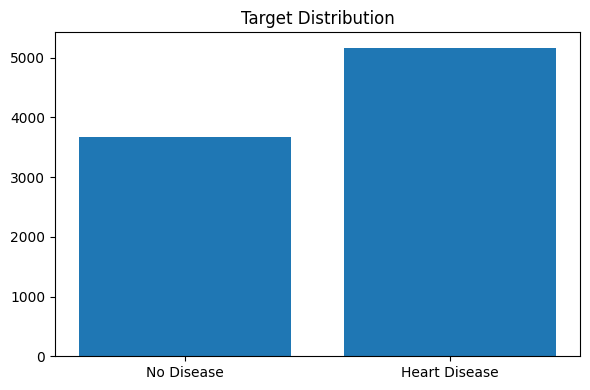

In [16]:
# 1️⃣ Target distribution
plt.figure(figsize=(6,4))
tc = df_eda['target'].value_counts().sort_index()
plt.bar(['No Disease', 'Heart Disease'], tc.values)
plt.title('Target Distribution')
plt.tight_layout()
plt.show()

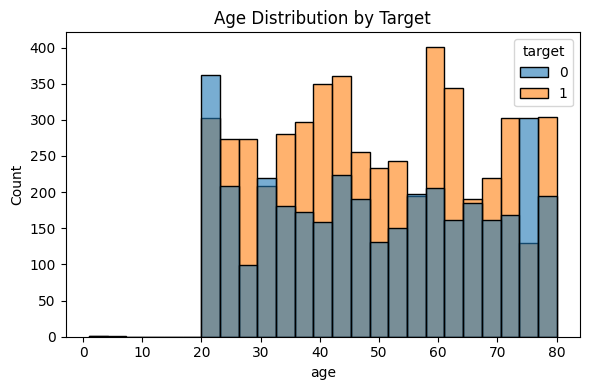

In [17]:
# 2️⃣ Age distribution by target
plt.figure(figsize=(6,4))
sns.histplot(data=df_eda, x='age', hue='target', bins=25, alpha=0.6)
plt.title('Age Distribution by Target')
plt.tight_layout()
plt.show()

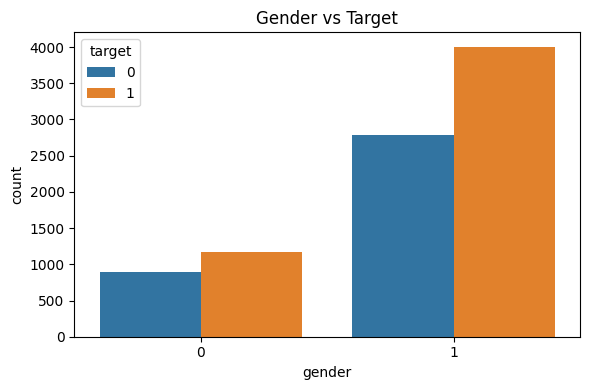

In [18]:
# 3️⃣ Gender vs target
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='gender', hue='target')
plt.title('Gender vs Target')
plt.tight_layout()
plt.show()

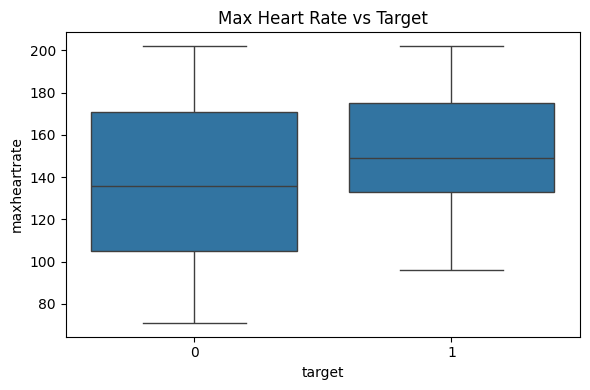

In [19]:
# 4️⃣ Max heart rate vs target
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x='target', y='maxheartrate')
plt.title('Max Heart Rate vs Target')
plt.tight_layout()
plt.show()

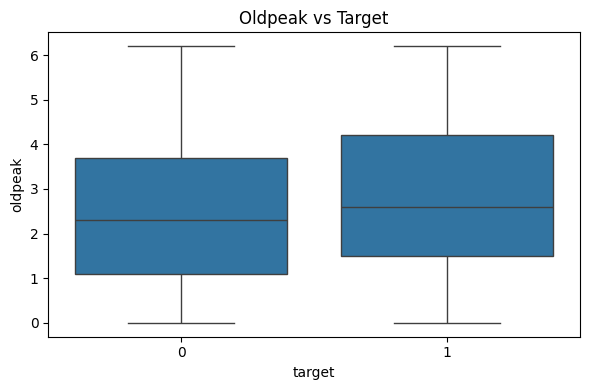

In [20]:
# 5️⃣ Oldpeak vs target
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x='target', y='oldpeak')
plt.title('Oldpeak vs Target')
plt.tight_layout()
plt.show()

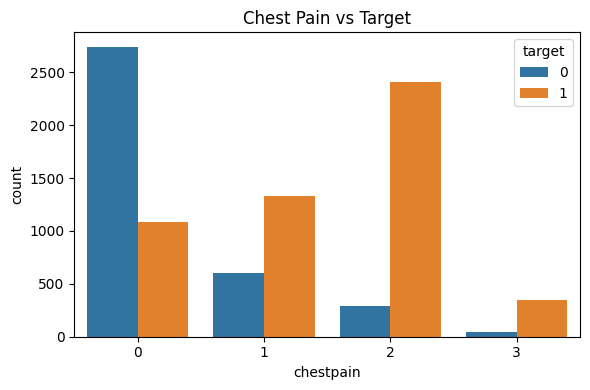

In [21]:
# 6️⃣ Chest pain vs target
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='chestpain', hue='target')
plt.title('Chest Pain vs Target')
plt.tight_layout()
plt.show()

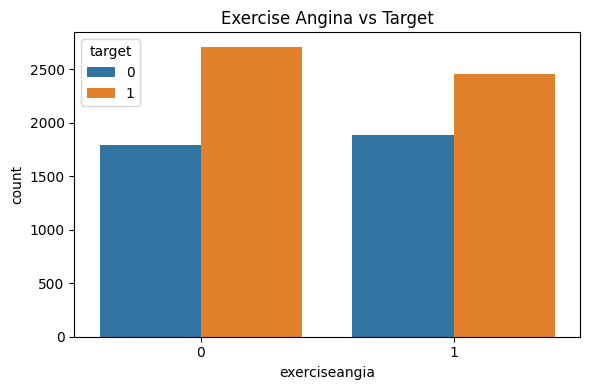

In [22]:
# 7️⃣ Exercise angina vs target
plt.figure(figsize=(6,4))
sns.countplot(data=df_eda, x='exerciseangia', hue='target')
plt.title('Exercise Angina vs Target')
plt.tight_layout()
plt.show()

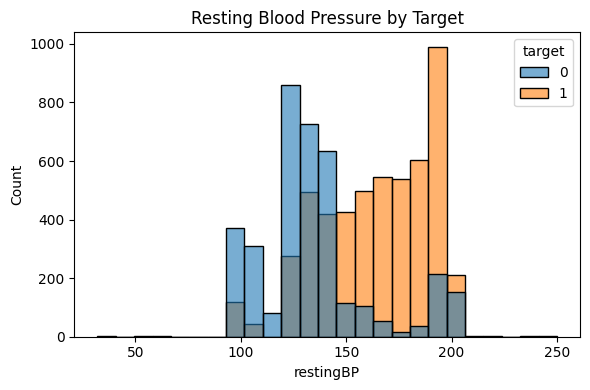

In [23]:
# 8️⃣ Resting BP distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df_eda, x='restingBP', hue='target', bins=25, alpha=0.6)
plt.title('Resting Blood Pressure by Target')
plt.tight_layout()
plt.show()

In [24]:
df_clean.head()

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,noofmajorvessels,target
0,53,1,2.0,171.0,NaN,0,1.0,147.0,0,5.3,3,1
1,40,1,0.0,94.0,229.0,0,1.0,115.0,0,3.7,1,0
2,49,1,2.0,133.0,142.0,0,0.0,202.0,1,5.0,0,0
3,43,1,0.0,138.0,295.0,1,1.0,153.0,0,3.2,2,1
4,31,1,1.0,199.0,NaN,0,2.0,136.0,0,5.3,2,1


In [25]:
print(df_eda['target'].value_counts())
print(df_eda['target'].value_counts(normalize=True) * 100)

target
1    5166
0    3678
Name: count, dtype: int64
target
1    58.412483
0    41.587517
Name: proportion, dtype: float64


In [26]:
print("y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

y_train:
target
1    5166
0    3678
Name: count, dtype: int64
target
1    58.412483
0    41.587517
Name: proportion, dtype: float64

y_test:
target
1    1292
0     919
Name: count, dtype: int64
target
1    58.435097
0    41.564903
Name: proportion, dtype: float64


In [27]:
xgb    = XGBClassifier(random_state=42, eval_metric='logloss')
rf     = RandomForestClassifier(random_state=42)
ann    = MLPClassifier(random_state=42, max_iter=500)
hybrid = VotingClassifier(
    estimators=[('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
                ('rf',  RandomForestClassifier(random_state=42))],
    voting='soft'
)

In [28]:
models = {
    'XGBoost'        : xgb,
    'Random Forest'  : rf,
    'ANN'            : ann,
    'Hybrid (XGB+RF)': hybrid
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained ✓")

XGBoost trained ✓
Random Forest trained ✓
ANN trained ✓
Hybrid (XGB+RF) trained ✓


In [29]:
# Evaluation
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

for name, model in models.items():
    evaluate(name, model, X_test, y_test)


  XGBoost
  Accuracy  : 0.9977
  Precision : 0.9977
  Recall    : 0.9985
  F1-Score  : 0.9981
  ROC-AUC   : 1.0000

  Random Forest
  Accuracy  : 0.9982
  Precision : 0.9985
  Recall    : 0.9985
  F1-Score  : 0.9985
  ROC-AUC   : 1.0000

  ANN
  Accuracy  : 0.9353
  Precision : 0.9471
  Recall    : 0.9420
  F1-Score  : 0.9445
  ROC-AUC   : 0.9783

  Hybrid (XGB+RF)
  Accuracy  : 0.9982
  Precision : 0.9985
  Recall    : 0.9985
  F1-Score  : 0.9985
  ROC-AUC   : 1.0000


In [30]:
# Train vs Test accuracy check
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

XGBoost              | Train: 1.0000 | Test: 0.9977
Random Forest        | Train: 1.0000 | Test: 0.9982
ANN                  | Train: 0.9334 | Test: 0.9353
Hybrid (XGB+RF)      | Train: 1.0000 | Test: 0.9982


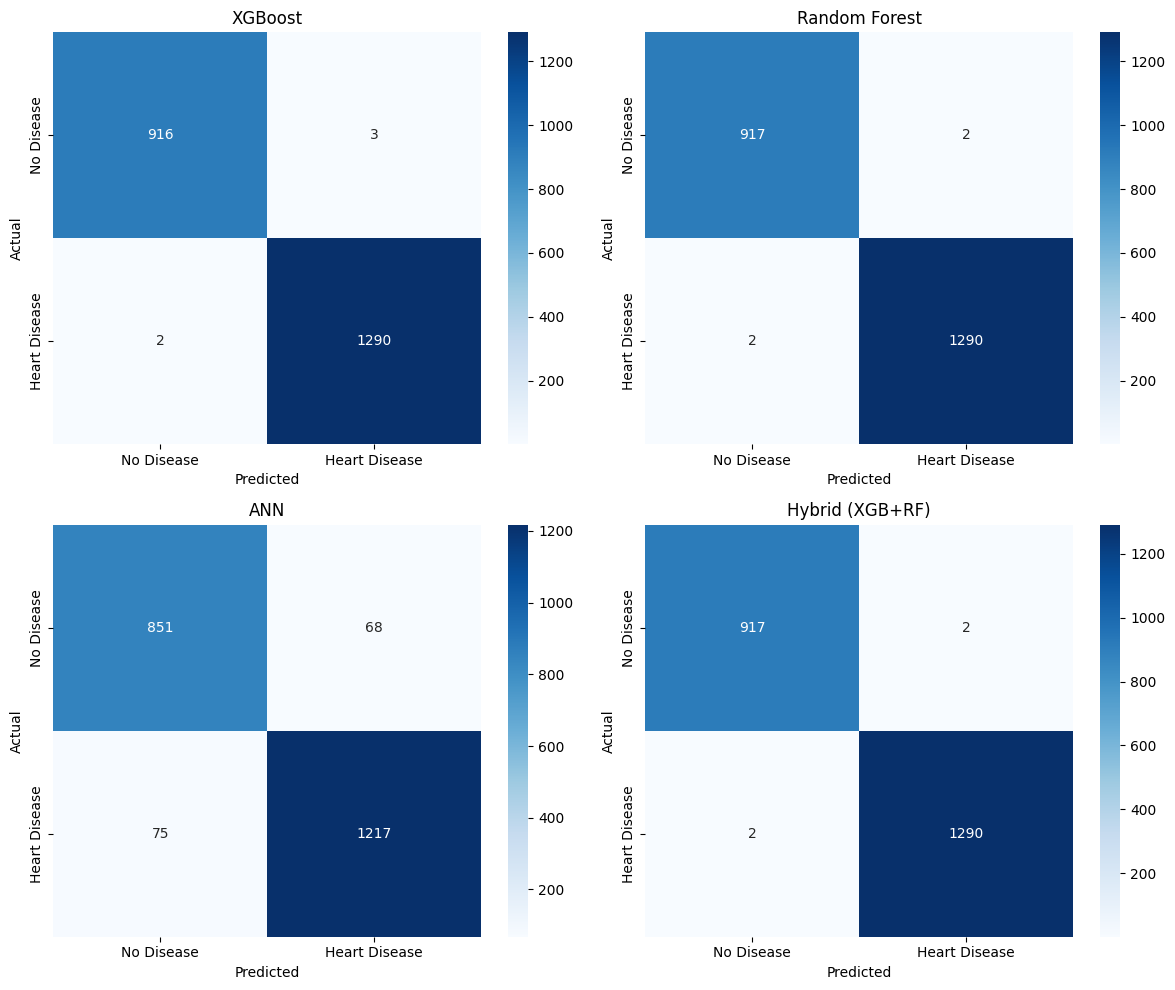

In [31]:
# Confusion Matrix
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
labels = ['No Disease', 'Heart Disease']

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

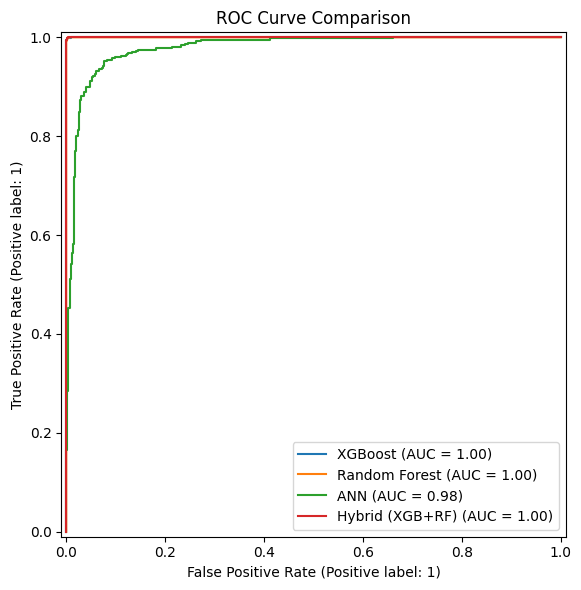

In [32]:
# ROC Curve
plt.figure(figsize=(8, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=plt.gca(), name=name)
plt.title('ROC Curve Comparison')
plt.tight_layout()
plt.show()

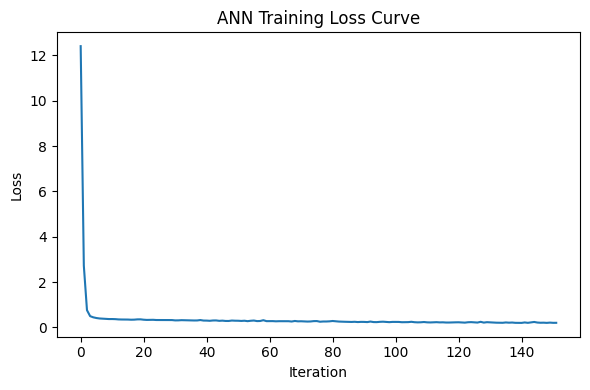

In [33]:
# ANN Loss Curve
ann_standalone = MLPClassifier(random_state=42, max_iter=500)
ann_standalone.fit(X_train, y_train)

plt.figure(figsize=(6,4))
plt.plot(ann_standalone.loss_curve_)
plt.title('ANN Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

In [70]:
# Save all model
for name, model in models.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('+', '').replace('/', '').strip()
    joblib.dump(model, f"{filename}.pkl")
    print(f"Saved: {filename}.pkl")

joblib.dump(impute_vals, 'impute_vals.pkl')
print("Saved: impute_vals.pkl")

Saved: xgboost.pkl
Saved: random_forest.pkl
Saved: ann.pkl
Saved: hybrid_xgbrf.pkl
Saved: impute_vals.pkl


In [42]:
joblib.dump(impute_vals, 'impute_vals.pkl')

['impute_vals.pkl']

In [34]:
# Best model based F1-Score
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    results[name] = f1_score(y_test, y_pred)

best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"Best Model: {best_name} (F1: {results[best_name]:.4f})")

joblib.dump(best_model, 'best_model.pkl')
print(f"Saved: best_model.pkl ({best_name})")

Best Model: Random Forest (F1: 0.9985)
Saved: best_model.pkl (Random Forest)


In [35]:
# Cek korelasi semua fitur dengan target
corr = df_eda.corr()['target'].abs().sort_values(ascending=False)
print(corr)

target               1.000000
chestpain            0.533534
restingBP            0.488485
noofmajorvessels     0.485523
restingrelectro      0.415753
serumcholestrol      0.366599
fastingbloodsugar    0.289078
maxheartrate         0.210342
oldpeak              0.100227
exerciseangia        0.037372
gender               0.019047
age                  0.005986
Name: target, dtype: float64


In [36]:
# Cek training accuracy vs test accuracy
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

XGBoost              | Train: 1.0000 | Test: 0.9977
Random Forest        | Train: 1.0000 | Test: 0.9982
ANN                  | Train: 0.9334 | Test: 0.9353
Hybrid (XGB+RF)      | Train: 1.0000 | Test: 0.9982


In [2]:
import joblib
model = joblib.load('best_model.pkl')
print(model.feature_names_in_)

['age' 'gender' 'chestpain' 'restingBP' 'serumcholestrol'
 'fastingbloodsugar' 'restingrelectro' 'maxheartrate' 'exerciseangia'
 'oldpeak' 'slope' 'noofmajorvessels']


In [37]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation F1:")
print("="*40)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name:20s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Cross Validation F1:
XGBoost              | Mean: 0.9972 | Std: 0.0006
Random Forest        | Mean: 0.9971 | Std: 0.0006
ANN                  | Mean: 0.9098 | Std: 0.0125
Hybrid (XGB+RF)      | Mean: 0.9975 | Std: 0.0004


In [38]:
# Define models dengan parameter baru
xgb = XGBClassifier(random_state=42, eval_metric='logloss',
                    max_depth=3, n_estimators=100, learning_rate=0.1)
rf  = RandomForestClassifier(random_state=42,
                    max_depth=5, n_estimators=100, min_samples_leaf=5)
ann = MLPClassifier(random_state=42, max_iter=500,
                    hidden_layer_sizes=(64, 32), alpha=0.01)
hybrid = VotingClassifier(
    estimators=[('xgb', XGBClassifier(random_state=42, eval_metric='logloss',
                                       max_depth=3, n_estimators=100, learning_rate=0.1)),
                ('rf',  RandomForestClassifier(random_state=42,
                                       max_depth=5, n_estimators=100, min_samples_leaf=5))],
    voting='soft'
)

models = {
    'XGBoost'        : xgb,
    'Random Forest'  : rf,
    'ANN'            : ann,
    'Hybrid (XGB+RF)': hybrid
}

# Train
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained ✓")

# Evaluasi
for name, model in models.items():
    evaluate(name, model, X_test, y_test)

# Train vs Test
print("\nTrain vs Test:")
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

XGBoost trained ✓
Random Forest trained ✓
ANN trained ✓
Hybrid (XGB+RF) trained ✓

  XGBoost
  Accuracy  : 0.9738
  Precision : 0.9732
  Recall    : 0.9822
  F1-Score  : 0.9777
  ROC-AUC   : 0.9974

  Random Forest
  Accuracy  : 0.9575
  Precision : 0.9545
  Recall    : 0.9737
  F1-Score  : 0.9640
  ROC-AUC   : 0.9913

  ANN
  Accuracy  : 0.9276
  Precision : 0.9805
  Recall    : 0.8940
  F1-Score  : 0.9352
  ROC-AUC   : 0.9853

  Hybrid (XGB+RF)
  Accuracy  : 0.9656
  Precision : 0.9627
  Recall    : 0.9791
  F1-Score  : 0.9708
  ROC-AUC   : 0.9960

Train vs Test:
XGBoost              | Train: 0.9729 | Test: 0.9738
Random Forest        | Train: 0.9559 | Test: 0.9575
ANN                  | Train: 0.9288 | Test: 0.9276
Hybrid (XGB+RF)      | Train: 0.9635 | Test: 0.9656


In [39]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation F1:")
print("="*40)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name:20s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Cross Validation F1:
XGBoost              | Mean: 0.9756 | Std: 0.0023
Random Forest        | Mean: 0.9601 | Std: 0.0026
ANN                  | Mean: 0.9212 | Std: 0.0168
Hybrid (XGB+RF)      | Mean: 0.9678 | Std: 0.0031


In [40]:
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss',
                    max_depth=3, n_estimators=100, learning_rate=0.1)

rf_base = RandomForestClassifier(random_state=42,
                    max_depth=5, n_estimators=100, min_samples_leaf=5)

# XGB dan RF di dalam hybrid dibuat lebih kuat
xgb_h = XGBClassifier(random_state=42, eval_metric='logloss',
                    max_depth=4, n_estimators=200, learning_rate=0.05)

rf_h = RandomForestClassifier(random_state=42,
                    max_depth=7, n_estimators=200, min_samples_leaf=3)

hybrid = VotingClassifier(
    estimators=[('xgb', xgb_h), ('rf', rf_h)],
    voting='soft',
    weights=[2, 1]  # XGB diberi bobot lebih besar
)

models = {
    'XGBoost'        : xgb_base,
    'Random Forest'  : rf_base,
    'ANN'            : ann,
    'Hybrid (XGB+RF)': hybrid
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained ✓")

for name, model in models.items():
    evaluate(name, model, X_test, y_test)

XGBoost trained ✓
Random Forest trained ✓
ANN trained ✓
Hybrid (XGB+RF) trained ✓

  XGBoost
  Accuracy  : 0.9738
  Precision : 0.9732
  Recall    : 0.9822
  F1-Score  : 0.9777
  ROC-AUC   : 0.9974

  Random Forest
  Accuracy  : 0.9575
  Precision : 0.9545
  Recall    : 0.9737
  F1-Score  : 0.9640
  ROC-AUC   : 0.9913

  ANN
  Accuracy  : 0.9276
  Precision : 0.9805
  Recall    : 0.8940
  F1-Score  : 0.9352
  ROC-AUC   : 0.9853

  Hybrid (XGB+RF)
  Accuracy  : 0.9891
  Precision : 0.9900
  Recall    : 0.9915
  F1-Score  : 0.9907
  ROC-AUC   : 0.9993


In [41]:
from sklearn.model_selection import cross_val_score

print("5-Fold Cross Validation F1:")
print("="*40)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    print(f"{name:20s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Cross Validation F1:
XGBoost              | Mean: 0.9756 | Std: 0.0023
Random Forest        | Mean: 0.9601 | Std: 0.0026
ANN                  | Mean: 0.9212 | Std: 0.0168
Hybrid (XGB+RF)      | Mean: 0.9885 | Std: 0.0031


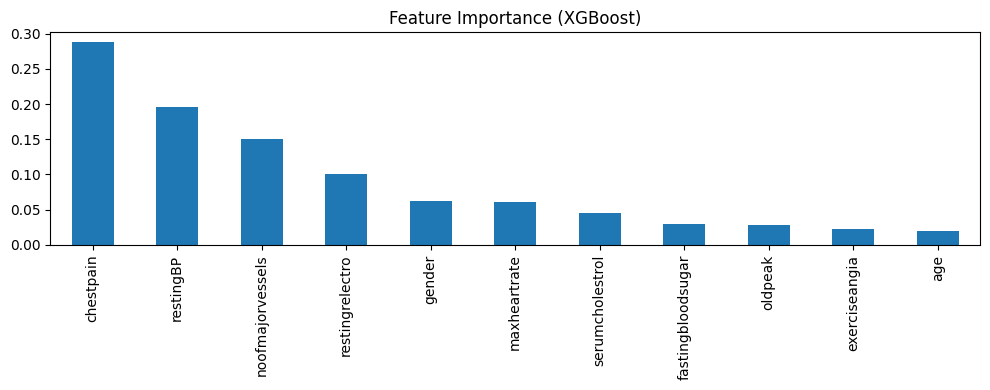

chestpain            0.287465
restingBP            0.195148
noofmajorvessels     0.149740
restingrelectro      0.100584
gender               0.061743
maxheartrate         0.061101
serumcholestrol      0.045062
fastingbloodsugar    0.029168
oldpeak              0.027709
exerciseangia        0.022775
age                  0.019505
dtype: float32


In [42]:
# Feature importance dari XGB di dalam hybrid
xgb_inside = models['Hybrid (XGB+RF)'].estimators_[0]
importances = pd.Series(xgb_inside.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,4))
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

In [43]:
selected_features = [
    'chestpain', 'restingBP', 'gender',
    'maxheartrate', 'serumcholestrol',
    'fastingbloodsugar', 'age'
]

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Define ulang models
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss',
                    max_depth=3, n_estimators=100, learning_rate=0.1)
rf_base  = RandomForestClassifier(random_state=42,
                    max_depth=5, n_estimators=100, min_samples_leaf=5)
ann      = MLPClassifier(random_state=42, max_iter=500,
                    hidden_layer_sizes=(64, 32), alpha=0.01)
xgb_h    = XGBClassifier(random_state=42, eval_metric='logloss',
                    max_depth=4, n_estimators=200, learning_rate=0.05)
rf_h     = RandomForestClassifier(random_state=42,
                    max_depth=7, n_estimators=200, min_samples_leaf=3)
hybrid   = VotingClassifier(
    estimators=[('xgb', xgb_h), ('rf', rf_h)],
    voting='soft', weights=[2, 1]
)

models = {
    'XGBoost'        : xgb_base,
    'Random Forest'  : rf_base,
    'ANN'            : ann,
    'Hybrid (XGB+RF)': hybrid
}

# Train
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    print(f"{name} trained ✓")

# Evaluasi
for name, model in models.items():
    evaluate(name, model, X_test_sel, y_test)

# Train vs Test
print("\nTrain vs Test:")
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_sel))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_sel))
    print(f"{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

XGBoost trained ✓
Random Forest trained ✓
ANN trained ✓
Hybrid (XGB+RF) trained ✓

  XGBoost
  Accuracy  : 0.9588
  Precision : 0.9532
  Recall    : 0.9776
  F1-Score  : 0.9652
  ROC-AUC   : 0.9948

  Random Forest
  Accuracy  : 0.9389
  Precision : 0.9282
  Recall    : 0.9706
  F1-Score  : 0.9489
  ROC-AUC   : 0.9866

  ANN
  Accuracy  : 0.9077
  Precision : 0.9066
  Recall    : 0.9389
  F1-Score  : 0.9224
  ROC-AUC   : 0.9588

  Hybrid (XGB+RF)
  Accuracy  : 0.9815
  Precision : 0.9868
  Recall    : 0.9814
  F1-Score  : 0.9841
  ROC-AUC   : 0.9980

Train vs Test:
XGBoost              | Train: 0.9630 | Test: 0.9588
Random Forest        | Train: 0.9369 | Test: 0.9389
ANN                  | Train: 0.9017 | Test: 0.9077
Hybrid (XGB+RF)      | Train: 0.9877 | Test: 0.9815


In [44]:
print("5-Fold Cross Validation F1:")
print("="*40)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sel, y_train, cv=5, scoring='f1')
    print(f"{name:20s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Cross Validation F1:
XGBoost              | Mean: 0.9641 | Std: 0.0052
Random Forest        | Mean: 0.9476 | Std: 0.0053
ANN                  | Mean: 0.9057 | Std: 0.0165
Hybrid (XGB+RF)      | Mean: 0.9845 | Std: 0.0024


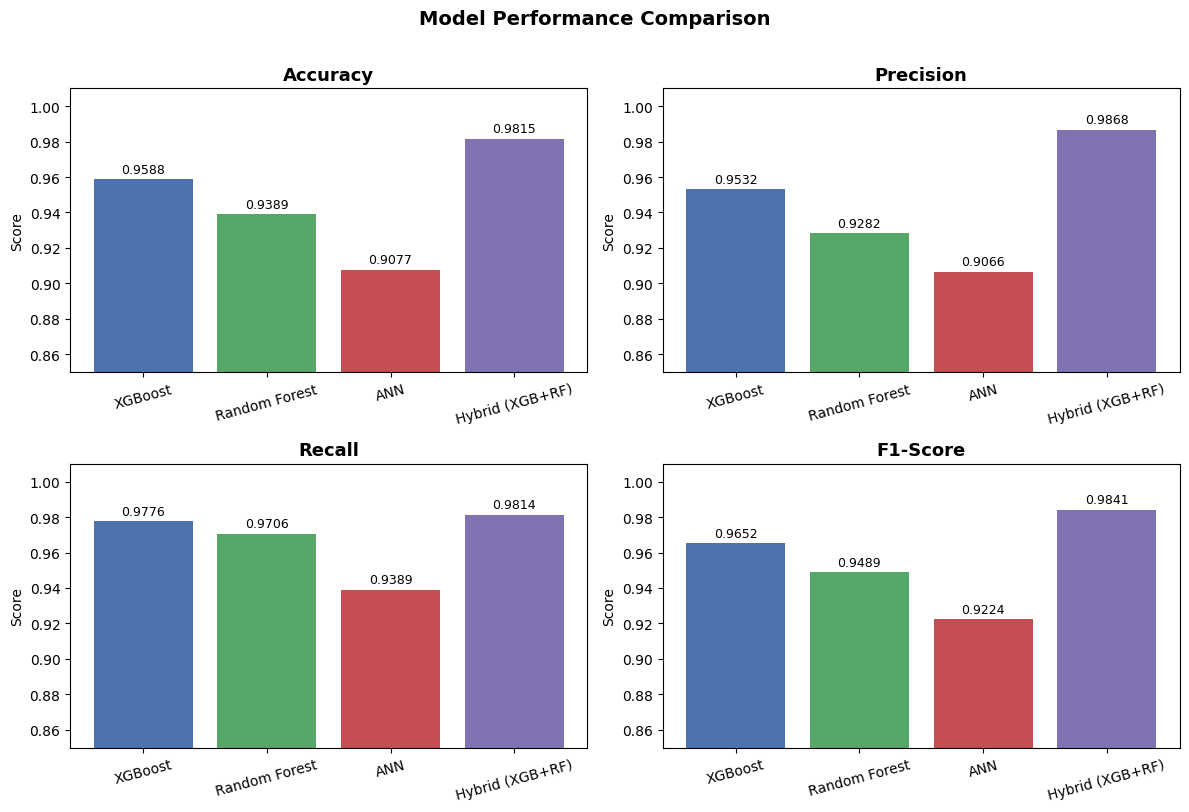

In [45]:
# Visualisasi perbandingan metrik semua model
metrics = {
    'Accuracy' : [accuracy_score(y_test, m.predict(X_test_sel)) for m in models.values()],
    'Precision': [precision_score(y_test, m.predict(X_test_sel)) for m in models.values()],
    'Recall'   : [recall_score(y_test, m.predict(X_test_sel)) for m in models.values()],
    'F1-Score' : [f1_score(y_test, m.predict(X_test_sel)) for m in models.values()],
}

model_names = list(models.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (metric_name, values) in enumerate(metrics.items()):
    bars = axes[i].bar(model_names, values, color=colors)
    axes[i].set_title(metric_name, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0.85, 1.01)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [46]:
# Save all models dengan selected features
for name, model in models.items():
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('+', '').replace('/', '').strip()
    joblib.dump(model, f"{filename}.pkl")
    print(f"Saved: {filename}.pkl")

# Save impute vals
joblib.dump(impute_vals, 'impute_vals.pkl')
print("Saved: impute_vals.pkl")

# Save selected features list
joblib.dump(selected_features, 'selected_features.pkl')
print("Saved: selected_features.pkl")

# Save best model (Hybrid)
joblib.dump(models['Hybrid (XGB+RF)'], 'best_model.pkl')
print("Saved: best_model.pkl (Hybrid XGB+RF)")

# Verifikasi
m = joblib.load('best_model.pkl')
print(f"\nVerifikasi best model:")
print(f"Type  : {type(m)}")
print(f"Fitur : {m.feature_names_in_}")
print(f"Jumlah: {len(m.feature_names_in_)}")

Saved: xgboost.pkl
Saved: random_forest.pkl
Saved: ann.pkl
Saved: hybrid_xgbrf.pkl
Saved: impute_vals.pkl
Saved: selected_features.pkl
Saved: best_model.pkl (Hybrid XGB+RF)

Verifikasi best model:
Type  : <class 'sklearn.ensemble._voting.VotingClassifier'>
Fitur : ['chestpain' 'restingBP' 'gender' 'maxheartrate' 'serumcholestrol'
 'fastingbloodsugar' 'age']
Jumlah: 7


In [2]:
import joblib
m = joblib.load('best_model.pkl')
print(list(m.feature_names_in_))

['chestpain', 'restingBP', 'gender', 'maxheartrate', 'serumcholestrol', 'fastingbloodsugar', 'age']


In [3]:
import sklearn, xgboost
print(sklearn.__version__)
print(xgboost.__version__)

1.6.1
3.2.0
